In [1]:
!pip install pandas

In [2]:
import pandas as pd
import sqlite3
from sqlite3 import Error

In [3]:
def create_connection(path):
    connection = None
    try:
        connection = sqlite3.connect(path)
    except Error as e:
        print(f"The error {e} occured")
    return connection

connection = create_connection("../checking-logs.sqlite")

In [4]:
pd.read_sql("SELECT * FROM checker", connection)

,index,status,success,timestamp,numTrials,labname,uid
0,0,checking,0,2020-04-16 21:12:50.740474,5,None,admin_1
1,1,ready,0,2020-04-16 21:12:54.708365,5,code_rvw,admin_1
2,2,checking,0,2020-04-16 21:46:47.769088,7,None,admin_1
3,3,ready,0,2020-04-16 21:46:48.121217,7,lab02,admin_1
4,4,checking,0,2020-04-16 21:53:01.862637,6,code_rvw,admin_1
...,...,...,...,...,...,...,...
3397,3397,ready,0,2020-05-21 20:19:06.872761,7,laba06s,user_1
3398,3398,checking,0,2020-05-21 20:22:41.785725,8,laba06s,user_1
3399,3399,ready,0,2020-05-21 20:22:41.877806,8,laba06s,user_1
3400,3400,checking,0,2020-05-21 20:37:00.129678,9,laba06s,user_1


In [5]:
query = """ 
SELECT
    SUM(CASE WHEN TIME(timestamp) BETWEEN '00:00:00' AND '03:59:59' THEN 1 ELSE 0 END) AS 'night',
    SUM(CASE WHEN TIME(timestamp) BETWEEN '04:00:00' AND '09:59:59' THEN 1 ELSE 0 END) AS 'morning',
    SUM(CASE WHEN TIME(timestamp) BETWEEN '10:00:00' AND '16:59:59' THEN 1 ELSE 0 END) AS 'afternoon',
    SUM(CASE WHEN TIME(timestamp) BETWEEN '17:00:00' AND '23:59:59' THEN 1 ELSE 0 END) AS 'evening',
    DATE(timestamp) AS date
FROM checker
WHERE uid LIKE 'user_%'
GROUP BY date;
"""

df = pd.read_sql(query, connection)

df

,night,morning,afternoon,evening,date
0,0,13,10,0,2020-04-17
1,0,1,33,35,2020-04-18
2,2,4,16,11,2020-04-19
3,0,0,12,13,2020-04-20
4,0,0,0,25,2020-04-21
5,0,0,4,24,2020-04-22
6,2,6,15,20,2020-04-23
7,0,0,4,12,2020-04-24
8,1,21,33,49,2020-04-25
9,2,8,86,165,2020-04-26


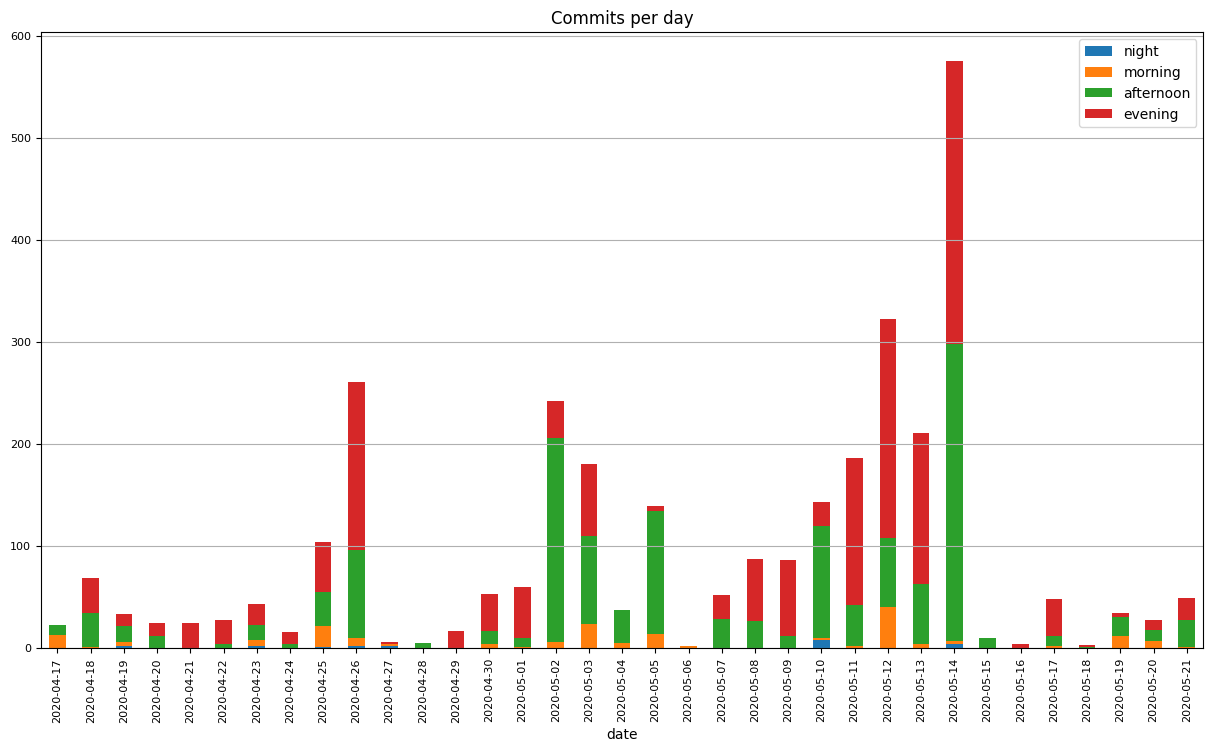

In [6]:
graf = df.plot.bar(x ="date", stacked="True", fontsize=8, figsize=(15,8), title="Commits per day")
graf.grid(axis="y")

#### When do our users usually commit the labs: in the night, morning, afternoon, or evening? Answer: afternoon, evening

#### At the same time, the number of commits in the evening is higher than in the afternoon? Answer: yes

In [7]:
connection.close()